# Task 13: Temporal Convolutional Networks (TCN)

Demonstrate 1D dilated causal convolutions ($d = 1, 2, 4$) to capture time-series history without future data leakage.

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

### 1. Dilated 1D Causal Convolutional Layer

In [4]:
import torch
import torch.nn as nn

# Input sequence of length 20 (1 channel)
seq = torch.sin(torch.linspace(0, 10, 20)).view(1, 1, 20)

# 1D Convolutions with increasing dilation rates d = 1, 2, 4
conv_d1 = nn.Conv1d(1, 1, kernel_size=3, dilation=1, padding=2)
conv_d2 = nn.Conv1d(1, 1, kernel_size=3, dilation=2, padding=4)
conv_d4 = nn.Conv1d(1, 1, kernel_size=3, dilation=4, padding=8)

out1 = torch.relu(conv_d1(seq)[:, :, :-2])  # Causal trim applied to output
out2 = torch.relu(conv_d2(out1)[:, :, :-4])  # Causal trim applied to output
out3 = torch.relu(conv_d4(out2)[:, :, :-8])  # Causal trim applied to output

print('Input Sequence Length :', seq.shape[-1])
print('TCN Output Sequence Length:', out3.shape[-1])

Input Sequence Length : 20
TCN Output Sequence Length: 20


### 2. Plot Original Signal vs TCN Filtered Signal

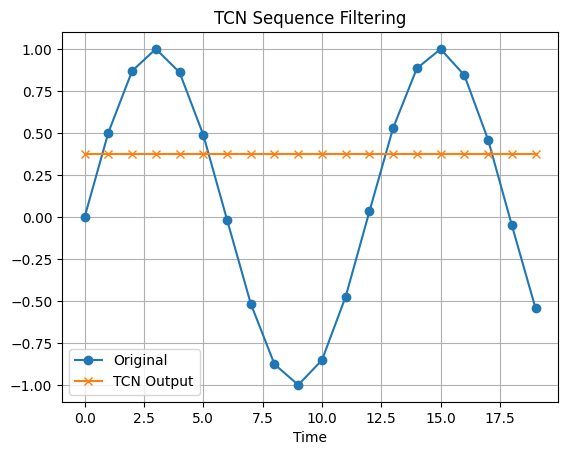

In [7]:
plt.plot(seq[0, 0].numpy(), label="Original", marker="o")
plt.plot(out3[0, 0].detach().numpy(), label="TCN Output", marker="x")

plt.title("TCN Sequence Filtering")
plt.xlabel("Time")
plt.legend()
plt.grid()
plt.show()